In [ ]:
import os
import tarfile

# Folder on E drive
data_dir = r"E:\BS AI\Seventh Semester\z23k-0052\cifar10_data"
tar_file = os.path.join(data_dir, "cifar-10-python.tar.gz")
dataset_folder = os.path.join(data_dir, "cifar-10-batches-py")

# Extract only if dataset folder doesn't exist
if not os.path.exists(dataset_folder):
    print("Extracting from local file...")
    with tarfile.open(tar_file, "r:gz") as tar:
        tar.extractall(data_dir)
        
    print("Extraction complete!")

print("Dataset location:", dataset_folder)

Extracting from local file...


C:\Users\Hp Elitebook 840 G3\AppData\Local\Temp\ipykernel_6104\1219863174.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_dir)


Extraction complete!
Dataset location: E:\BS AI\Seventh Semester\z23k-0052\cifar10_data\cifar-10-batches-py


In [4]:
import pickle
import numpy as np
import os
from tensorflow.keras.utils import to_categorical

# Correct dataset location
base_dir = r"E:\BS AI\Seventh Semester\z23k-0052\cifar10_data\cifar-10-batches-py"

def load_batch(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f, encoding="bytes")
    return data[b"data"], data[b"labels"]

# Optional: verify the folder before loading
print("Dataset exists:", os.path.exists(base_dir))
print("Files:", os.listdir(base_dir))

# Load training data
x_train = []
y_train = []

for i in range(1, 6):
    x, y = load_batch(
        os.path.join(base_dir, f"data_batch_{i}")
    )
    x_train.append(x)
    y_train.extend(y)

x_train = np.concatenate(x_train)
y_train = np.array(y_train)

# Load test data
x_test, y_test = load_batch(
    os.path.join(base_dir, "test_batch")
)

# Reshape images
x_train = x_train.reshape(-1, 3, 32, 32)
x_test = x_test.reshape(-1, 3, 32, 32)

# Convert from (channels, height, width)
# to (height, width, channels)
x_train = x_train.transpose(0, 2, 3, 1)
x_test = x_test.transpose(0, 2, 3, 1)

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encoding
NUM_CLASSES = 10

y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)


Dataset exists: True
Files: ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']
x_train: (50000, 32, 32, 3)
y_train: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)


In [5]:
x_train[54, 12, 13, 1]


np.float32(0.36862746)

In [9]:
from tensorflow.keras import layers, models

input_layer = layers.Input(shape=(32, 32, 3))

x = layers.Flatten()(input_layer)

x = layers.Dense(200, activation="relu")(x)

x = layers.Dense(150, activation="relu")(x)

output_layer = layers.Dense(10, activation="softmax")(x)

model = models.Model(input_layer, output_layer)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       614,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 150)            │        30,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,260 (2.47 MB)

 Trainable params: 646,260 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras import optimizers

opt = optimizers.Adam(learning_rate=0.0005)

model.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)


In [12]:
history = model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_split=0.1
)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.3281 - loss: 1.8671 - val_accuracy: 0.3772 - val_loss: 1.7386
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 23ms/step - accuracy: 0.3938 - loss: 1.6897 - val_accuracy: 0.4168 - val_loss: 1.6404
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 28ms/step - accuracy: 0.4266 - loss: 1.6019 - val_accuracy: 0.4322 - val_loss: 1.5968
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.4458 - loss: 1.5522 - val_accuracy: 0.4606 - val_loss: 1.5284
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.4653 - loss: 1.5101 - val_accuracy: 0.4616 - val_loss: 1.5376
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.4748 - loss: 1.4752 - val_accuracy: 0.4782 - val_loss: 1.4743
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.4844 - loss: 1.4513 - val_accuracy: 0.4448 - val_loss: 1.5763
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 26ms/step - accuracy: 0.4960 -

In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4878 - loss: 1.4510
Test Loss: 1.4509929418563843
Test Accuracy: 0.4878000020980835


In [16]:
import numpy as np
import matplotlib.pyplot as plt

CLASSES = np.array([
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
])


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


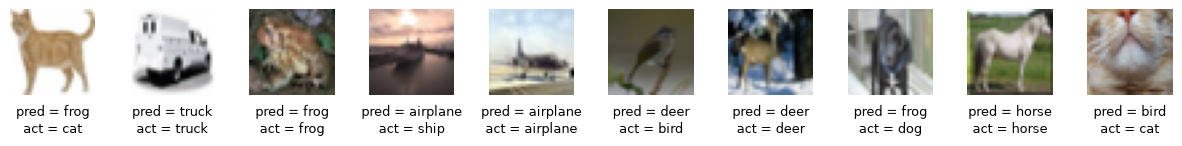

In [17]:
preds = model.predict(x_test)

preds_single = CLASSES[np.argmax(preds, axis=-1)]
actual_single = CLASSES[np.argmax(y_test, axis=-1)]

n_to_show = 10

indices = np.random.choice(
    range(len(x_test)),
    n_to_show,
    replace=False
)

fig = plt.figure(figsize=(15, 4))
fig.subplots_adjust(
    hspace=0.4,
    wspace=0.4
)

for i, idx in enumerate(indices):

    img = x_test[idx]

    ax = fig.add_subplot(1, n_to_show, i + 1)

    ax.axis("off")

    ax.text(
        0.5,
        -0.25,
        "pred = " + str(preds_single[idx]),
        fontsize=9,
        ha="center",
        transform=ax.transAxes
    )

    ax.text(
        0.5,
        -0.45,
        "act = " + str(actual_single[idx]),
        fontsize=9,
        ha="center",
        transform=ax.transAxes
    )

    ax.imshow(img)

plt.show()


In [18]:
input_layer = layers.Input(shape=(64,64,1))

input_layer = layers.Input(shape=(32, 32, 3))

conv_layer_1 = layers.Conv2D(
    filters=10,
    kernel_size=(4, 4),
    strides=2,
    padding="same",
    activation="relu"
)(input_layer)

conv_layer_2 = layers.Conv2D(
    filters=20,
    kernel_size=(3, 3),
    strides=2,
    padding="same",
    activation="relu"
)(conv_layer_1)

flatten_layer = layers.Flatten()(conv_layer_2)

output_layer = layers.Dense(
    units=10,
    activation="softmax"
)(flatten_layer)

cnn_model = models.Model(
    input_layer,
    output_layer
)

cnn_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 10)     │           490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 20)       │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,120 (59.06 KB)

 Trainable params: 15,120 (59.06 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
cnn_model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizers.Adam(learning_rate=0.0005),
    metrics=["accuracy"]
)

cnn_history = cnn_model.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_split=0.1
)

cnn_loss, cnn_accuracy = cnn_model.evaluate(
    x_test,
    y_test
)

print("CNN Test Loss:", cnn_loss)
print("CNN Test Accuracy:", cnn_accuracy)


Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.3858 - loss: 1.7392 - val_accuracy: 0.4542 - val_loss: 1.5555
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.4746 - loss: 1.4823 - val_accuracy: 0.4974 - val_loss: 1.4365
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 14ms/step - accuracy: 0.5097 - loss: 1.3848 - val_accuracy: 0.5172 - val_loss: 1.3711
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.5312 - loss: 1.3263 - val_accuracy: 0.5400 - val_loss: 1.3123
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.5470 - loss: 1.2838 - val_accuracy: 0.5456 - val_loss: 1.2835
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 12ms/step - accuracy: 0.5579 - loss: 1.2484 - val_accuracy: 0.5566 - val_loss: 1.2616
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.5698 - loss: 1.2184 - val_accuracy: 0.5680 - val_loss: 1.2234
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.5806 -

In [20]:
layers.BatchNormalization(momentum = 0.9)

input_layer = layers.Input(shape=(32, 32, 3))

x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    strides=1,
    padding="same"
)(input_layer)

x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(
    filters=32,
    kernel_size=3,
    strides=2,
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(
    filters=64,
    kernel_size=3,
    strides=1,
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Conv2D(
    filters=64,
    kernel_size=3,
    strides=2,
    padding="same"
)(x)

x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Flatten()(x)

x = layers.Dense(128)(x)

x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

x = layers.Dropout(rate=0.5)(x)

output_layer = layers.Dense(
    10,
    activation="softmax"
)(x)

model_bn = models.Model(
    input_layer,
    output_layer
)

model_bn.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

In [21]:
opt = optimizers.Adam(
    learning_rate=0.0005
)

model_bn.compile(
    loss="categorical_crossentropy",
    optimizer=opt,
    metrics=["accuracy"]
)

history_bn = model_bn.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=10,
    shuffle=True,
    validation_split=0.1
)

test_loss, test_accuracy = model_bn.evaluate(
    x_test,
    y_test
)

print("Final CNN Test Loss:", test_loss)
print("Final CNN Test Accuracy:", test_accuracy)



Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 144s 94ms/step - accuracy: 0.4427 - loss: 1.6010 - val_accuracy: 0.5468 - val_loss: 1.2569
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.5866 - loss: 1.1722 - val_accuracy: 0.5840 - val_loss: 1.2062
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 123s 87ms/step - accuracy: 0.6433 - loss: 1.0238 - val_accuracy: 0.6468 - val_loss: 1.0146
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 155s 96ms/step - accuracy: 0.6753 - loss: 0.9290 - val_accuracy: 0.6924 - val_loss: 0.8830
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 154s 105ms/step - accuracy: 0.6982 - loss: 0.8689 - val_accuracy: 0.6686 - val_loss: 0.9340
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 170s 81ms/step - accuracy: 0.7138 - loss: 0.8182 - val_accuracy: 0.6994 - val_loss: 0.8677
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 129s 91ms/step - accuracy: 0.7289 - loss: 0.7720 - val_accuracy: 0.7220 - val_loss: 0.8196
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 138s 98ms/step - accuracy:

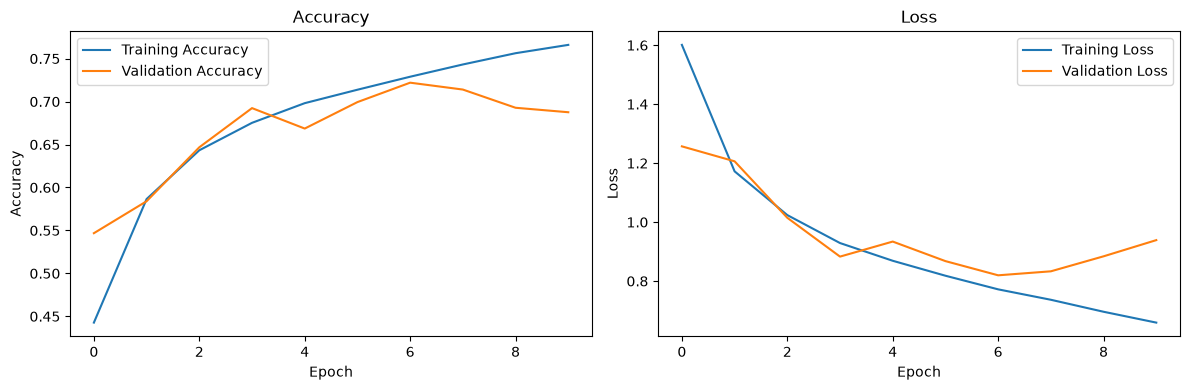

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_bn.history["accuracy"], label="Training Accuracy")
plt.plot(history_bn.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history_bn.history["loss"], label="Training Loss")
plt.plot(history_bn.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.tight_layout()
plt.show()
